Simple model for circle data using TensorFlow/Keras.


In [1]:
import numpy as np
from sklearn.model_selection import train_test_split

def gen_circles(N):
    N2=int(N/2)
    r_p=np.random.uniform(0.0,0.4,N2)
    r_n=np.random.uniform(0.6,0.8,N2)
    angle_p=np.random.uniform(0,2*np.pi,N2)
    angle_n=np.random.uniform(0,2*np.pi,N2)
    X_p = np.stack((r_p*np.sin(angle_p), r_p*np.cos(angle_p)), axis=1)
    X_n = np.stack((r_n*np.sin(angle_n), r_n*np.cos(angle_n)), axis=1)
    y_p = np.ones((N2, 1))
    y_n = np.zeros((N2, 1))

    return np.concatenate((X_p, X_n)), np.concatenate((y_p, y_n))
    
# generate and plot
N = 1000
X, y = gen_circles(N)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, shuffle = True)

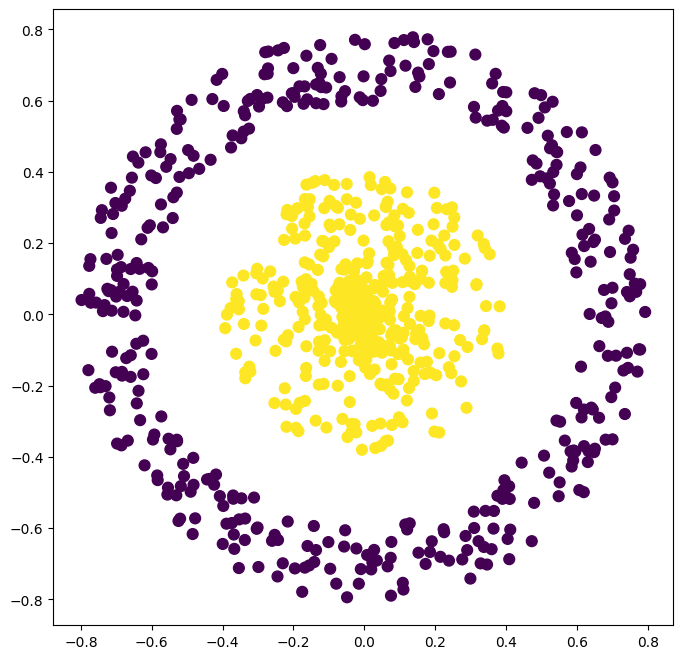

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.scatter(X_train[:,0], X_train[:,1],s=60,c=y_train)
plt.show()


In [3]:
import keras
from keras.layers import Dense,Input
from keras import Sequential

In [4]:
print(X_train.shape)
print(y_train.shape)

(800, 2)
(800, 1)


In [5]:
model=Sequential([
    Input(shape=(2,)),
    Dense(2,activation='relu'),
    Dense(1,activation='sigmoid'),
])

model.summary()

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy',metrics=['accuracy'])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history=model.fit(X_train,y_train,epochs=20,batch_size=4,validation_data=(X_valid,y_valid), verbose=True)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4600 - loss: 0.7034 - val_accuracy: 0.4300 - val_loss: 0.6927
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4638 - loss: 0.6871 - val_accuracy: 0.5450 - val_loss: 0.6811
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5275 - loss: 0.6742 - val_accuracy: 0.5600 - val_loss: 0.6716
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5387 - loss: 0.6637 - val_accuracy: 0.5700 - val_loss: 0.6636
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5700 - loss: 0.6545 - val_accuracy: 0.6050 - val_loss: 0.6568
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5938 - loss: 0.6465 - val_accuracy: 0.6050 - val_loss: 0.6507
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6087 - loss: 0.6393 - val_accuracy: 0.6150 - val_loss: 0.6450
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6212 - loss: 0.6324 - val_accuracy: 0.

<function matplotlib.pyplot.show(close=None, block=None)>

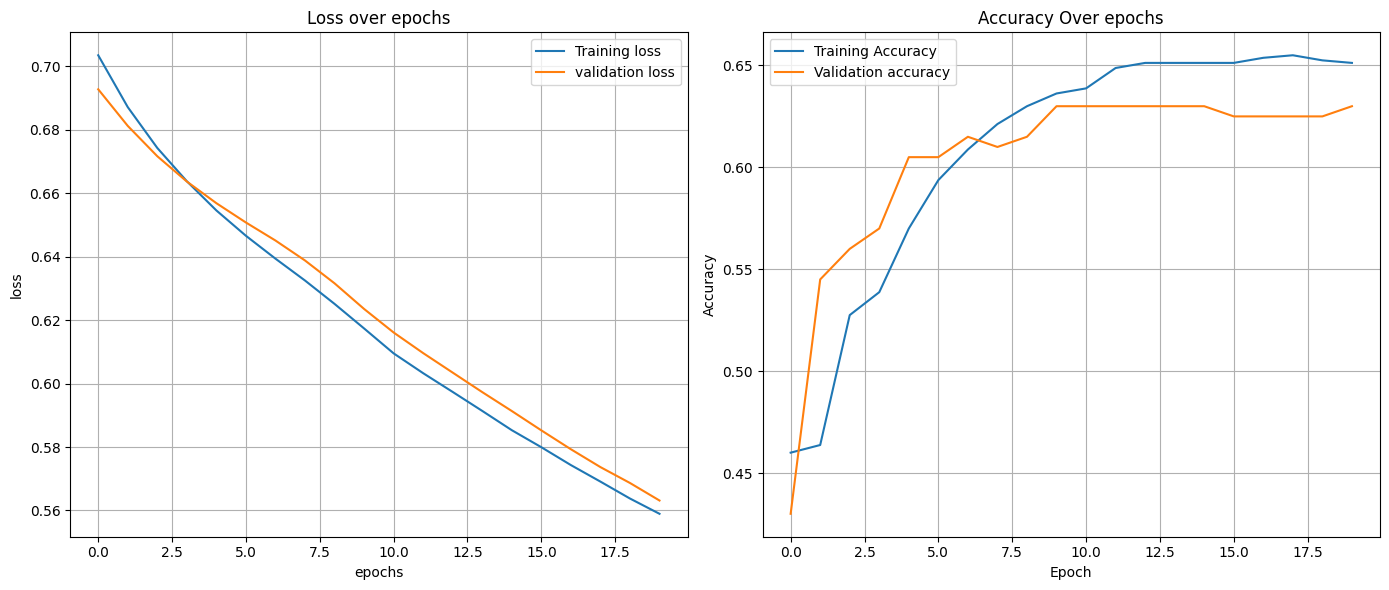

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='validation loss')
plt.title('Loss over epochs')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Accuracy Over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()
plt.tight_layout()
plt.show